# $f\sigma_8(z)$ with mochi_class

Install mochi-class as follows (in terminal):

- git clone https://github.com/mcataneo/mochi_class_public/tree/main
- cd mochi_class_public/
- make clean
- make 

Debug if needed! Work with python lower than ~ 3.11

In [1]:
import numpy as np, matplotlib.pyplot as plt
from classy import Class

Z = np.linspace(0., 1., 100)

LCDM = {'omega_b': 0.02238, 'omega_cdm': 0.1201, 'h': 0.6732,
        'n_s': 0.966, 'A_s': 2.1e-9, 'N_ur': 3.044,
        'output': 'mPk', 'P_k_max_h/Mpc': 10.,
        'z_max_pk': Z.max() , 
        'background_verbose': 0, 'input_verbose': 0}
_gr = Class()
_gr.set(LCDM)
_gr.compute()
OM_DE0 = 0.6847    
OM_SMG0 = 1. - _gr.Omega_m() - _gr.Omega_r()     


Now class implements Horndeski models through the given of some parameters (see the hi_class.ini file for more explanations):

- `Omega_fld`: 'fld' is for fluid. We don't use it here so set to zero

- `Omega_smg`: 'smg' is for scalar modified gravity. We want it and we want class to infer its omega for us. The rule to do this is to set it to -1.

- `gravity_model`: can be different models, either phenomenological ones or real scalar fields. Here we will use

- `expansion_model`: the expansion model, can be `lcdm`, `w0wa` or `wede`

- `expansion_smg`: the parameters of the expansion model. For `lcdm` it is just Omega_Lambda

- `parameters_smg`: parameters of the theoretical model. Here it will just be the list: c_K, c_B, c_M, c_T and M_*

In [2]:
def fs8(cM=0, cB=0, cK=1.):
    '''f*sigma_8(z) straight from CLASS. cM=cB=0 -> GR.'''
    '''cK has no impact so ignore it'''
    p = dict(LCDM)
    if cM != 0:
        p.update({'Omega_Lambda': 0, 'Omega_fld': 0, 'Omega_smg': -1,
                  'gravity_model': 'propto_omega', 'expansion_model': 'lcdm',
                  'expansion_smg': OM_DE0,
                  'parameters_smg': f'{cK}, {cB}, {cM}, 0., 1.'  })
    M = Class()
    M.set(p)
    M.compute()
    y = np.array([M.effective_f_sigma8(z) for z in Z])
    M.empty()
    return y

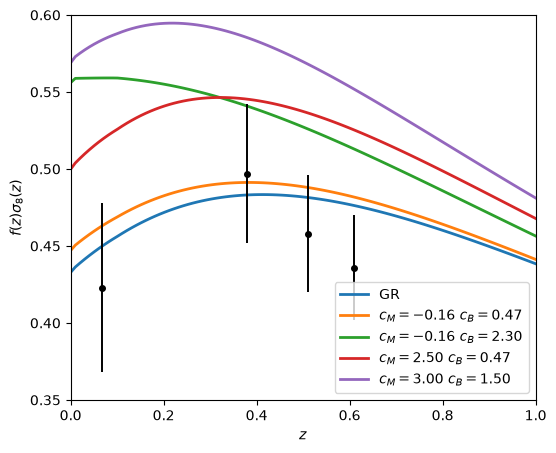

In [4]:
MODELS = [(0, 0, 'GR'),
          (-0.16, 0.47, r'$c_{M}=-0.16\ c_{B}=0.47$'),
          (-0.16, 2.30, r'$c_{M}=-0.16\ c_{B}=2.30$'),
          ( 2.50, 0.47, r'$c_{M}=2.50\ c_{B}=0.47$'),
          ( 3.00, 1.50, r'$c_{M}=3.00\ c_{B}=1.50$')]

# 6dFGS (Beutler+2012) and BOSS DR12 (Alam+2017)
DATA = np.array([[0.067, 0.423, 0.055], [0.38, 0.497, 0.045],
                 [0.51,  0.458, 0.038], [0.61, 0.436, 0.034]])

fig, ax = plt.subplots(figsize=(6, 5))
for aM, aB, lab in MODELS:
    y = fs8(aM, aB)
    ax.plot(Z, y, lw=2, label=lab)
ax.errorbar(DATA[:, 0], DATA[:, 1], yerr=DATA[:, 2], fmt='o', color='k', ms=4, lw=1.4)

ax.set_xlim(0, 1)
ax.set_ylim(0.35, 0.60)
ax.set_xlabel('$z$')
ax.set_ylabel(r'$f(z)\sigma_8(z)$')
plt.legend()
plt.savefig('../pictures/fs8_horndeski.png',dpi=300)
plt.show()